# [LAB 06] 데이터 시각화 - 15. Sub Plot

## #01. 준비작업 

In [1]:
from jussam import load_data
from matplotlib import pyplot as plt 
from helpers import my_plot
from pandas import pivot_table
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 불러오기 

In [2]:
origin = load_data('traffic_acc')
origin.head()

📚 2005년 1월 부터 2018년 12월 까지 월별 교통사고의 발생건수,부상자수,사망자수 데이터(인덱스/메타데이터 없음, 출처: 공공데이터포털)


,년도,월,발생건수,사망자수,부상자수
0,2005,1,15494,504,25413
1,2005,2,13244,431,21635
2,2005,3,16580,477,25550
3,2005,4,17817,507,28131
4,2005,5,19085,571,29808


### 3. 데이터 전처리 

In [3]:
df = origin.drop('월', axis=1).groupby('년도').mean()
df.head()

,발생건수,사망자수,부상자수
년도,,,
2005,17847.583,531.333,28519.417
2006,17812.083,527.250,28352.417
2007,17638.500,513.833,27992.167
2008,17985.167,489.167,28246.833
2009,19332.500,486.500,30156.250


### 4. 히트맵을 위한 데이터 재배치 

In [4]:
heatmap_df = pivot_table(origin, index='년도', columns='월', values='발생건수')
heatmap_df.head()


월,1,2,3,4,5,6,7,8,9,10,11,12
년도,,,,,,,,,,,,
2005,15494.000,13244.000,16580.000,17817.000,19085.000,18092.000,18675.000,19035.000,18759.000,19757.000,19129.000,18504.000
2006,14971.000,14270.000,16767.000,17948.000,19140.000,17435.000,18634.000,18794.000,19293.000,19100.000,19877.000,17516.000
2007,14914.000,14696.000,18166.000,18055.000,19264.000,18310.000,18037.000,17982.000,18506.000,19026.000,17815.000,16891.000
2008,14741.000,14176.000,16752.000,17498.000,19515.000,18824.000,19562.000,18545.000,18023.000,19926.000,19597.000,18663.000
2009,16532.000,15502.000,18224.000,19153.000,20237.000,19249.000,20281.000,19993.000,21004.000,21440.000,20156.000,20219.000


### 5. 파이 그래프를 위한 데이터 집계 

In [5]:
pie_df = origin[['월','발생건수']].groupby('월').sum().reset_index()
pie_df.head()

,월,발생건수
0,1,226934
1,2,208446
2,3,245893
3,4,257820
4,5,273934


## #02. 서브 플롯 초기화 

### 1. 2행 3열을 구성하는 서브플롯 초기화 (1/2)


findfont: Failed to find font weight 500, now using 400.


총 2개의 ax 객체가 생성되었습니다.


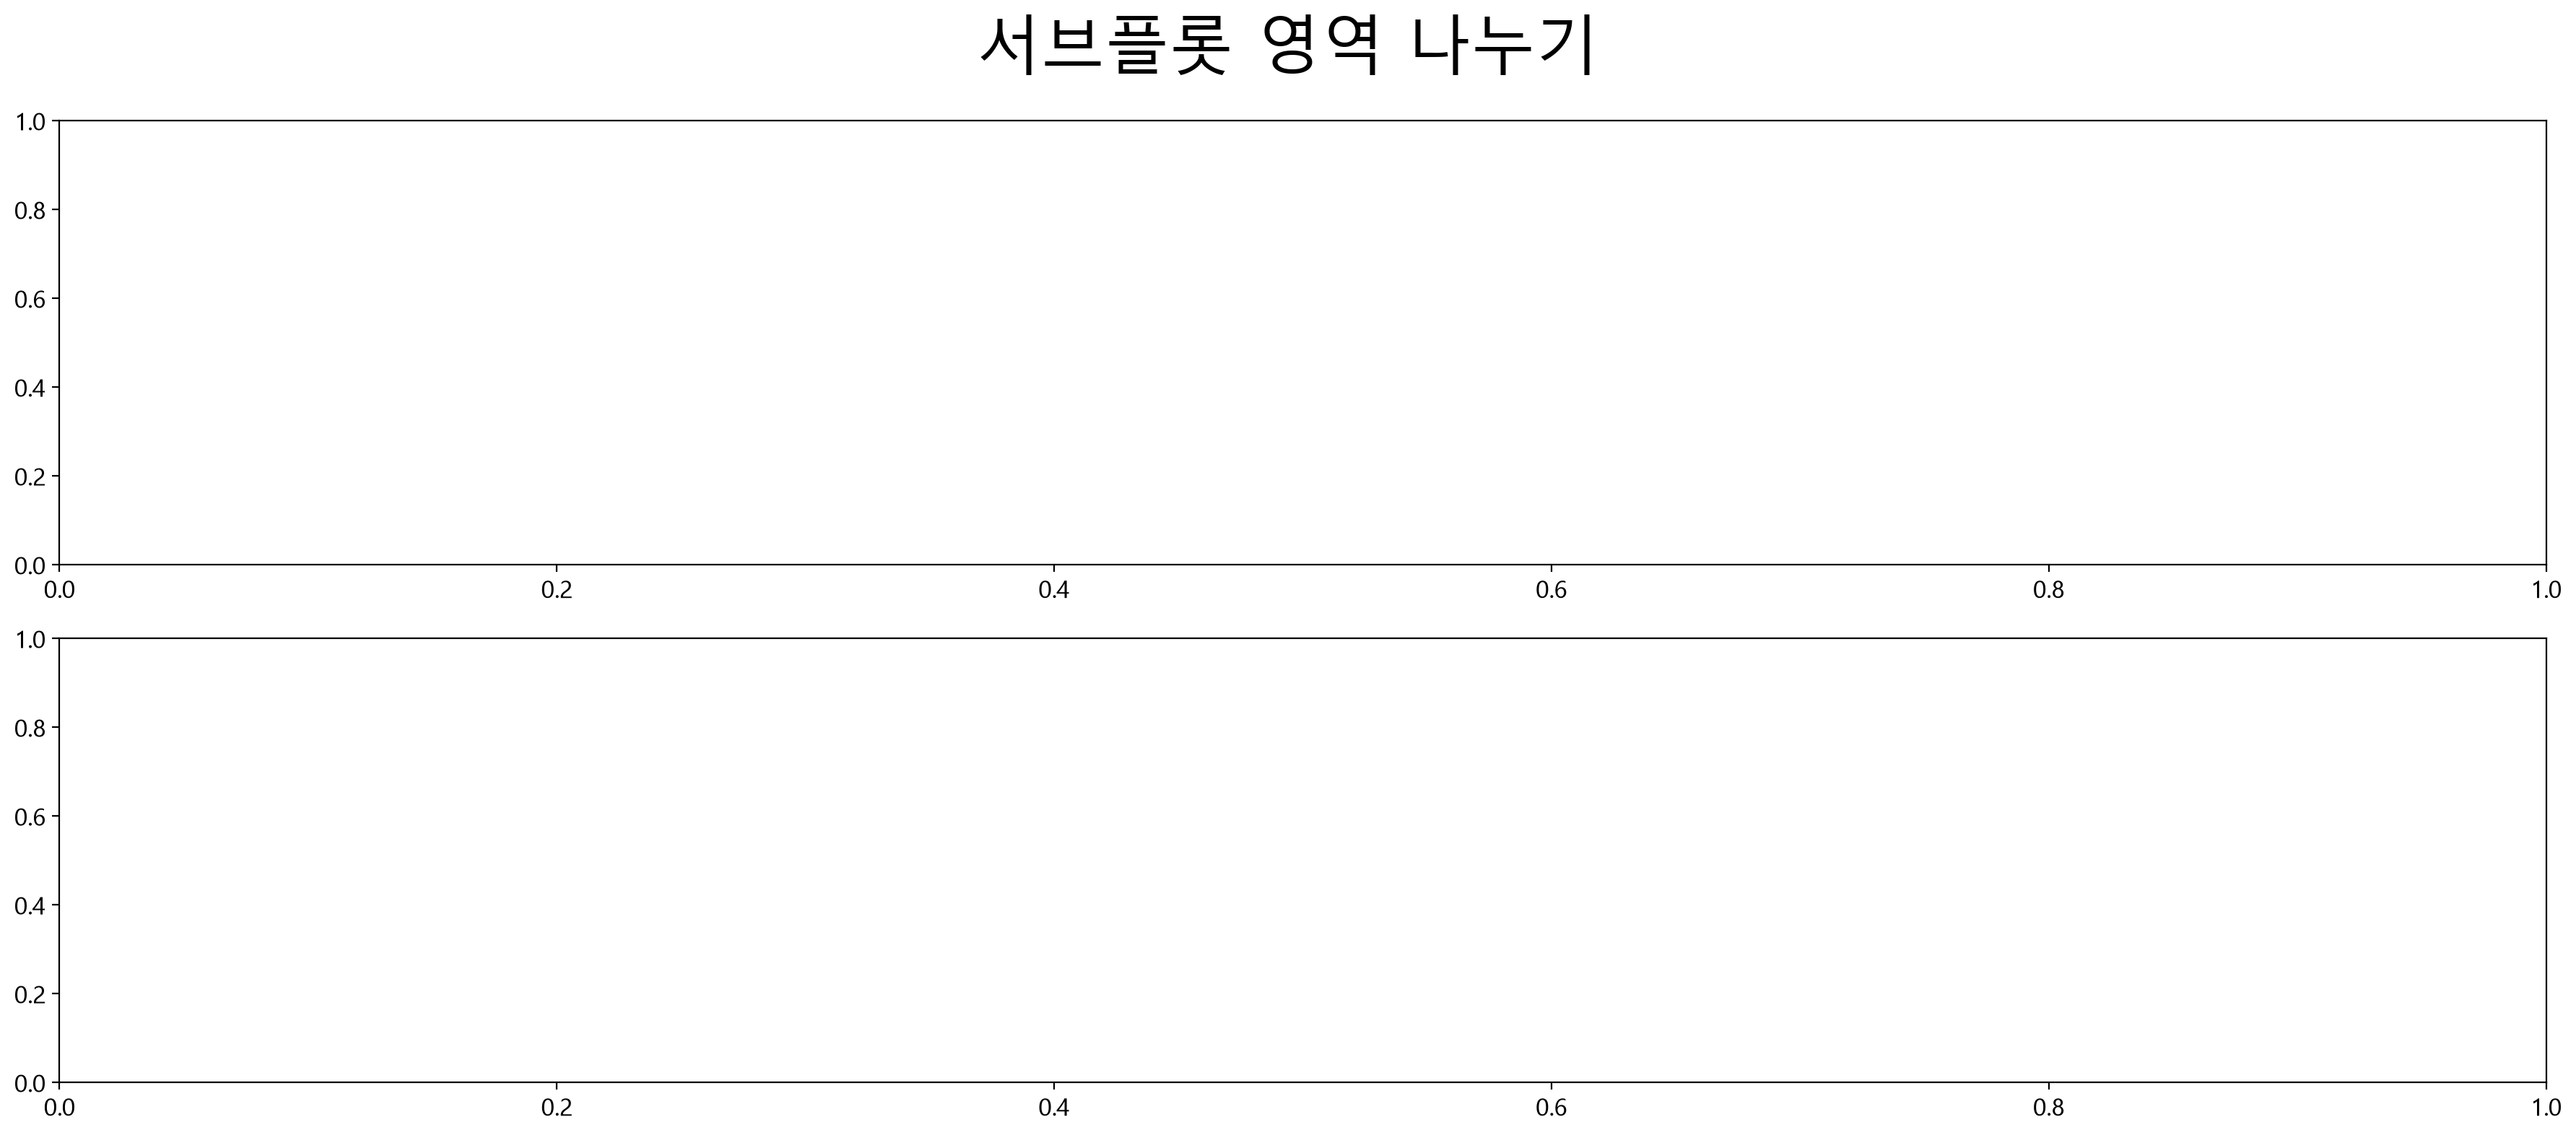

In [6]:
# 1) 그래프 초기화 
width = 600 # 그래프 하나의 가로 크기 
height = 400 # 그래프 하나의 세로 크기 
rows = 2 # 그래프 행 수 
cols = 3 # 그래프 열 수 
my_dpi = 200 # 그래프 해상도 
figsize = (width * cols / 100, height * rows / 100)

# ax 객체가 행, 열 수에 따라서 리스트가 된다. 
fig, ax = plt.subplots(rows, figsize=figsize, dpi=my_dpi)
ax = ax.flatten()

print(f'총 {len(ax)}개의 ax 객체가 생성되었습니다.')

# 2) 그래프 그리기 

# 3) 그래프 꾸미기 
# 전체 제목 
fig.suptitle('서브플롯 영역 나누기', fontsize=32, fontweight=500)

# 4) 출력 
plt.tight_layout() # 여백 제거 
plt.show() # 그래프 화면 출력 
plt.close() # 그래프 작업 종료 

총 6개의 ax객체가 생성되었습니다. 


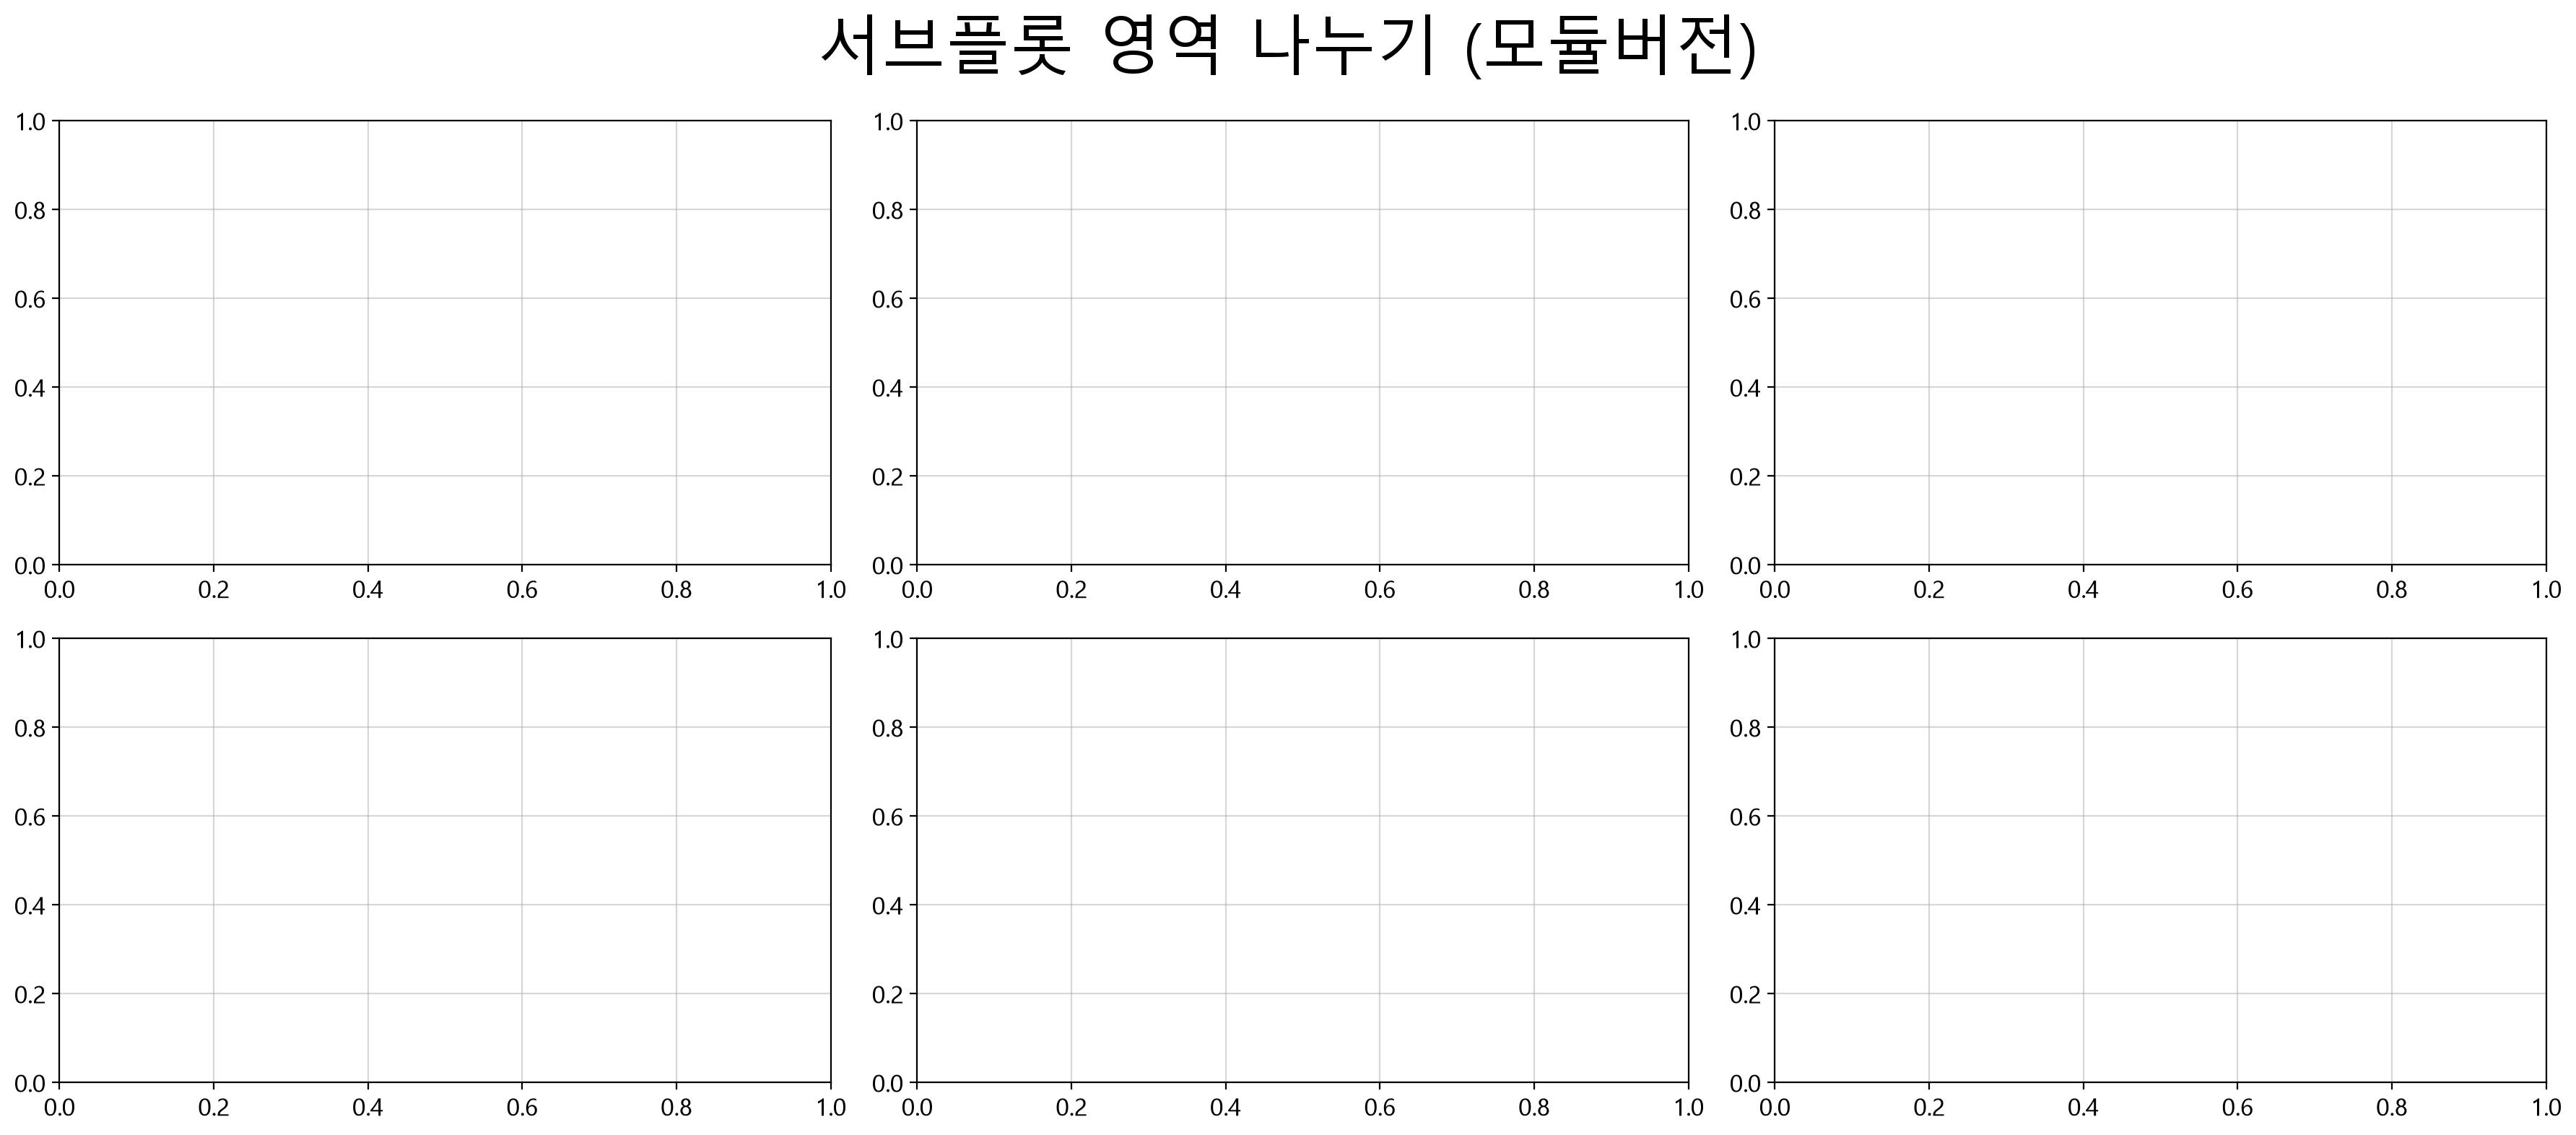

In [7]:
fig, ax = my_plot.init(width=600, height=400, rows=2, cols=3,
                       title='서브플롯 영역 나누기 (모듈버전)')

print(f'총 {len(ax)}개의 ax객체가 생성되었습니다. ')

my_plot.show()

## #03. 서브 플롯에 그래프 표시하기 

### 1. seaborn을 사용하여 직접 구현하기 

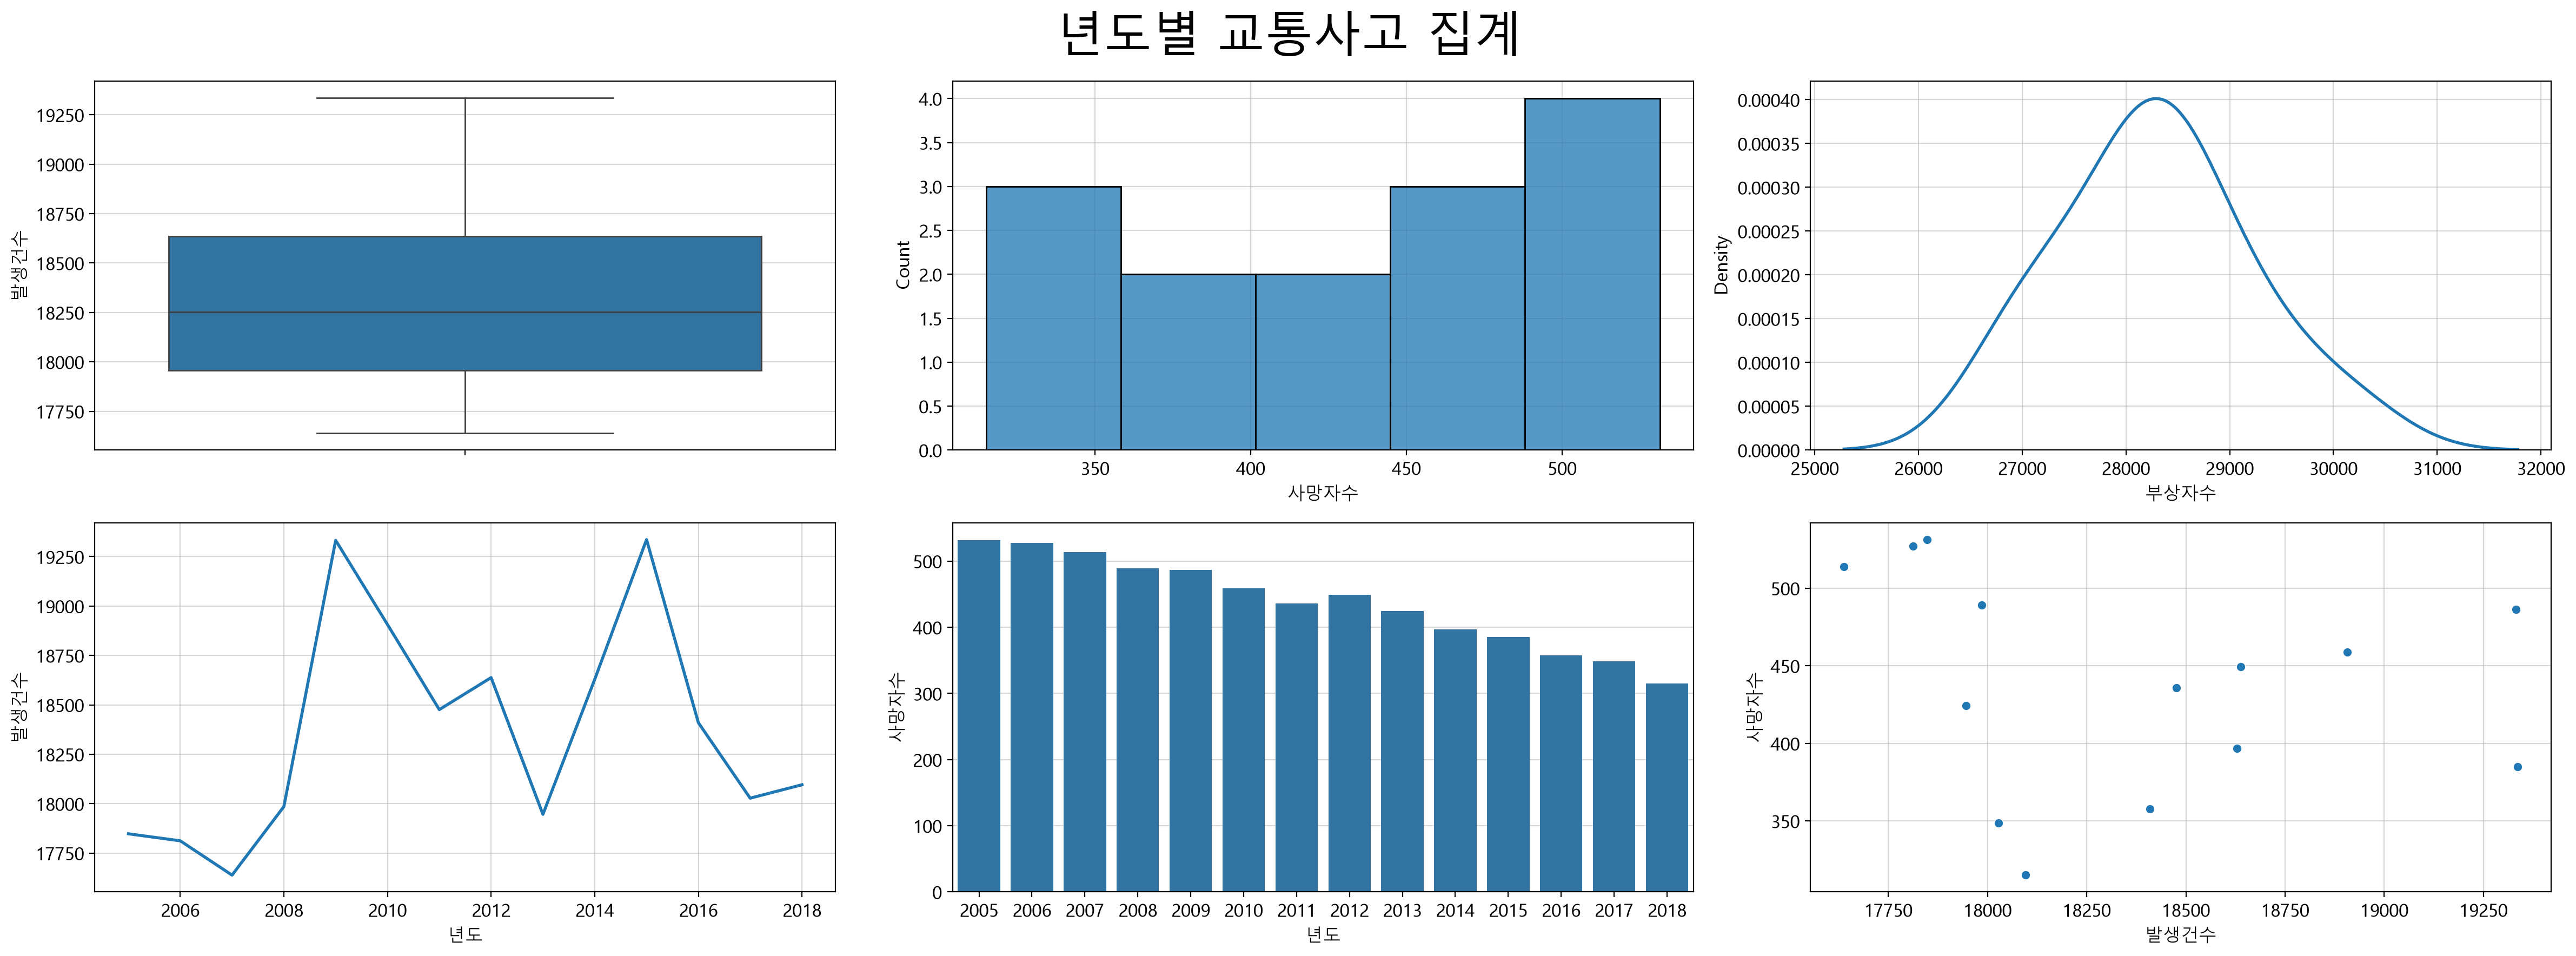

In [8]:
# 1) 그래프 초기화 
fig, ax = my_plot.init(rows=2, cols=3, width=800, height=450, 
                       title='년도별 교통사고 집계')

# 2) 그래프 그리기 
sb.boxplot(data=df, y='발생건수', ax=ax[0])
sb.histplot(data=df, x='사망자수', bins=5, ax=ax[1])
sb.kdeplot(data=df, x='부상자수', ax=ax[2])
sb.lineplot(data=df, x=df.index, y='발생건수', ax=ax[3])
sb.barplot(data=df, x=df.index, y='사망자수', estimator=np.sum, ax=ax[4])
sb.scatterplot(data=df, x='발생건수', y='사망자수', ax=ax[5])

# 3) 출력 
my_plot.show()

### 2. 모듈을 활용하여 지금까지 살펴본 모든 그래프 표시하기 

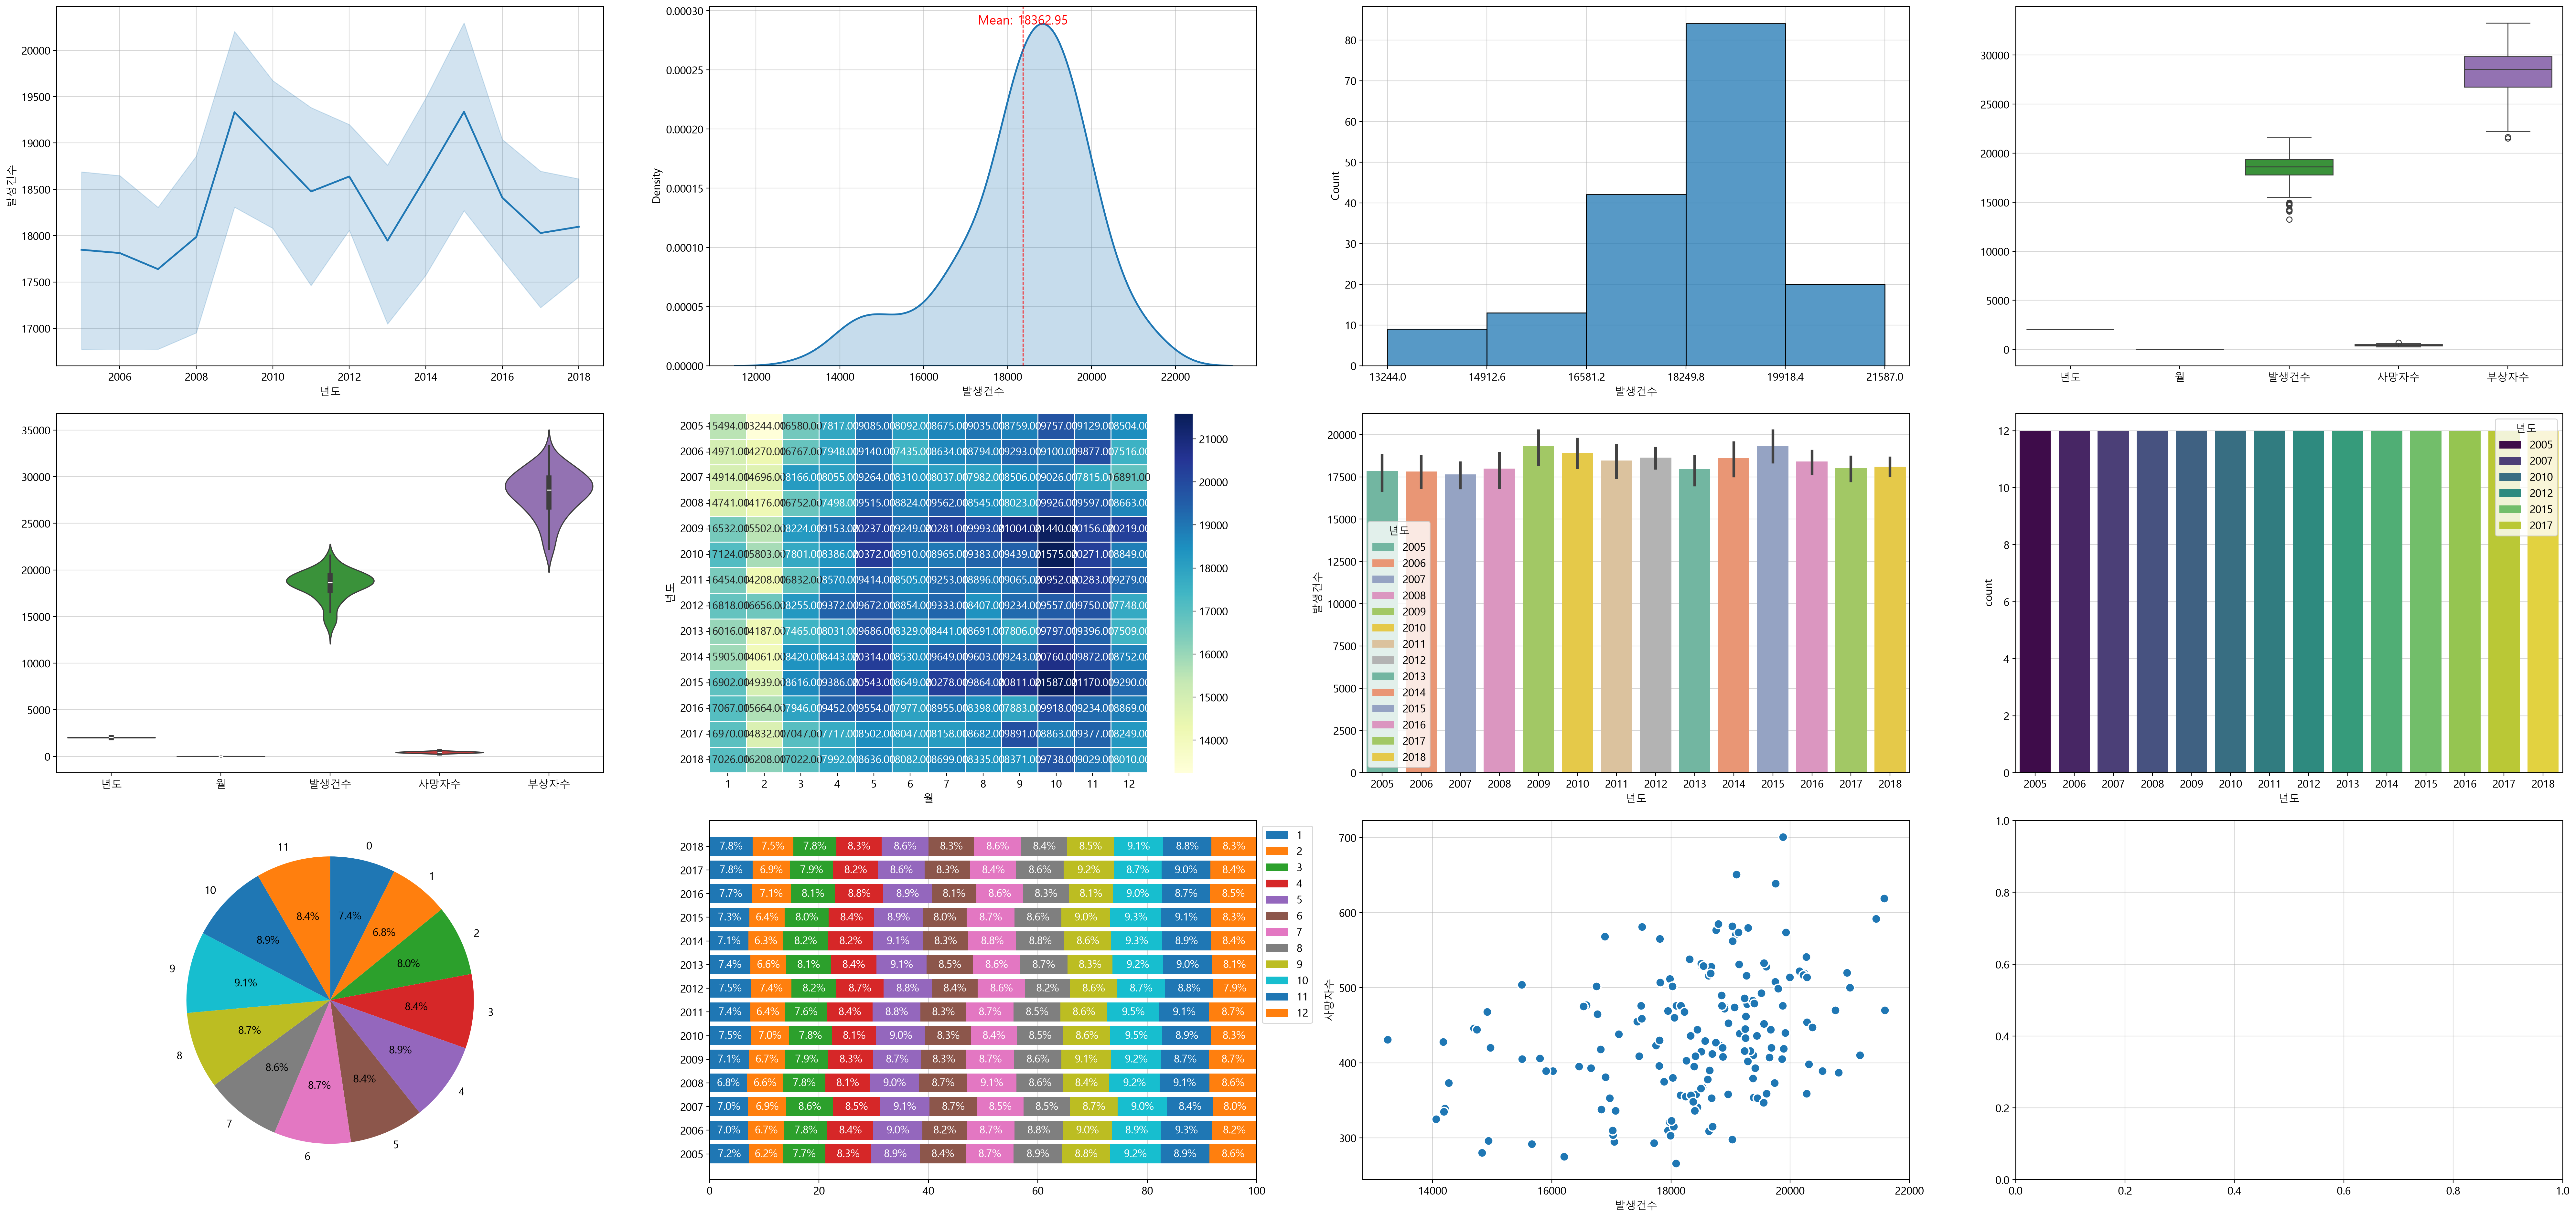

In [9]:
# 그래프 초기화 
fig, ax = my_plot.init(rows=3, cols=4, width=1000, height=640)

# 시계열 그래프 
my_plot.lineplot(data=origin, x='년도', y='발생건수', ax=ax[0])

# 2) 그래프 그리기 
my_plot.kdeplot(data=origin, x='발생건수', fill=True, meanline=True,  ax=ax[1])
my_plot.histplot(data=origin, x='발생건수', bins=5, ax=ax[2])
my_plot.boxplot(data=origin, ax=ax[3])
my_plot.violinPlot(data=origin, ax=ax[4])
my_plot.heatmap(data=heatmap_df, palette='YlGnBu', ax=ax[5])

# 집단별 비교 시각화 
my_plot.barplot(data=origin, x='년도', y='발생건수', hue='년도',
                palette='Set2', ax=ax[6])
my_plot.countplot(data=origin, x='년도', hue='년도', palette='viridis',
                  ax=ax[7])
my_plot.pieplot(x=pie_df['발생건수'], labels=pie_df.index, ax=ax[8])
my_plot.stackplot(data=origin, x='년도', y='발생건수', hue='월', ratio=True,
                  orient='h', ax=ax[9]) 

# 데이터 관계 시각화 
my_plot.scatterplot(data=origin, x='발생건수', y='사망자수', palette='tab10',
                    ax=ax[10])

# 3) 출력 
my_plot.show()
